In [4]:
# Nettoyage complet
print("Nettoyage...")
%reset -f
%whos

Nettoyage...
Interactive namespace is empty.


In [5]:
import numpy.random as rd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import pandas as pd 
from sqlalchemy import create_engine
from sqlalchemy.engine import URL
from sqlalchemy import text
import sqlalchemy
import gc
import pyodbc
from datetime import datetime
from pandas import NaT
import math
from scipy.stats import expon
import geopandas as gpd
from shapely.geometry import Point
import contextily as ctx
from geopy.geocoders import Nominatim
from geopy.exc import GeocoderTimedOut, GeocoderUnavailable
import time
from scipy.stats import gaussian_kde
from sklearn.neighbors import KernelDensity

In [6]:
# Connexion pyodbc à SQL Server

conn_str = (
    "DRIVER={ODBC Driver 17 for SQL Server};"
    "SERVER=172.16.11.33;"
    "DATABASE=LogiProDev;"
    "UID=quentin;"
    "PWD={Barbidur1;SQL}"
)

conn = pyodbc.connect(conn_str)
cursor = conn.cursor()

In [7]:
requete_gestion_de_lots_negociateurs = """
-- Requête comptage du nombre de lots qui ont été un jour en contact avec chaque négociateur
-- Pour trouver la distribution de l'"efficacité" des négociateurs

SELECT
    n.negociateur_id,
    n.neg_nom,
    n.neg_prenom,
    n.neg_actif,
    COUNT(DISTINCT tj.lot_id) AS nombre_lots_associes
FROM dbo.t_negociateur n
LEFT JOIN dbo.t_offre o
    ON o.negociateur_id = n.negociateur_id
LEFT JOIN dbo.tj_offre_lot tj
    ON tj.offre_id = o.offre_id
GROUP BY
    n.negociateur_id,
    n.neg_nom,
    n.neg_prenom,
    n.neg_actif
HAVING COUNT(DISTINCT tj.lot_id) != 0
"""

requete_transactions_revenus_negociateurs =""" 
-- Maintenant, requête qui va chercher le nombre de transactions qu'ont fait chaque négociateur, 
-- et les revenus que ça a rapporté. Le but est de trouver leur spécialisation sur la base des recettes 
-- par transaction, mais aussi de comparer la quantité de lots avec lesquels ils ont été en contact
-- avec la quantité de transactions dans lesquelles ils vont être impliqués par la suite

SELECT
    n.negociateur_id,
    n.neg_nom,
    n.neg_prenom,
    n.neg_actif,
    n.groupe_id,
    n.agence_id,
    COUNT(t.transaction_id) AS nombre_transactions,
    SUM(t.tra_loyer) AS montant_total_transactions
FROM dbo.t_negociateur n
LEFT JOIN dbo.t_transaction t
    ON t.negociateur_id = n.negociateur_id
GROUP BY
    n.negociateur_id,
    n.neg_nom,
    n.neg_prenom,
    n.neg_actif,
    n.groupe_id,
    n.agence_id
HAVING COUNT(t.transaction_id) > 0
"""

In [8]:
gestion_de_lots_negociateurs = pd.read_sql_query(requete_gestion_de_lots_negociateurs, conn)
print(gestion_de_lots_negociateurs.columns)

transactions_revenus_negociateurs = pd.read_sql_query(requete_transactions_revenus_negociateurs, conn)
print(transactions_revenus_negociateurs.columns)

C:\Users\quent\AppData\Local\Temp\ipykernel_14872\4072927372.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  gestion_de_lots_negociateurs = pd.read_sql_query(requete_gestion_de_lots_negociateurs, conn)


Index(['negociateur_id', 'neg_nom', 'neg_prenom', 'neg_actif',
       'nombre_lots_associes'],
      dtype='object')


C:\Users\quent\AppData\Local\Temp\ipykernel_14872\4072927372.py:4: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  transactions_revenus_negociateurs = pd.read_sql_query(requete_transactions_revenus_negociateurs, conn)


Index(['negociateur_id', 'neg_nom', 'neg_prenom', 'neg_actif', 'groupe_id',
       'agence_id', 'nombre_transactions', 'montant_total_transactions'],
      dtype='object')


In [9]:
conn.commit()
cursor.close()
conn.close()

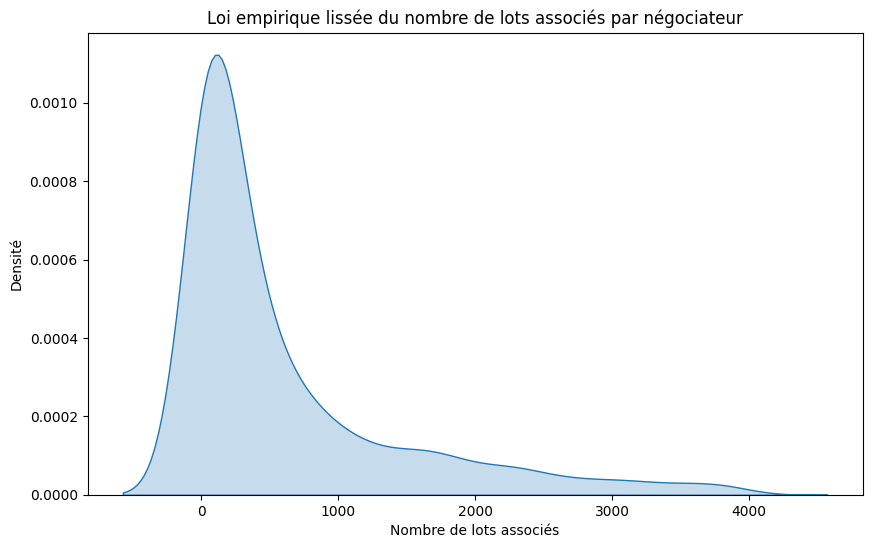

In [10]:
# On commence par éliminer les outliers

gestion_de_lots_negociateurs = gestion_de_lots_negociateurs[gestion_de_lots_negociateurs["nombre_lots_associes"] < 4000]
gestion_de_lots_negociateurs = gestion_de_lots_negociateurs[gestion_de_lots_negociateurs["nombre_lots_associes"] > 5]

plt.figure(figsize=(10, 6))
sns.kdeplot(data=gestion_de_lots_negociateurs, x='nombre_lots_associes', fill=True, bw_adjust=1)
plt.title("Loi empirique lissée du nombre de lots associés par négociateur")
plt.xlabel("Nombre de lots associés")
plt.ylabel("Densité")
plt.show()

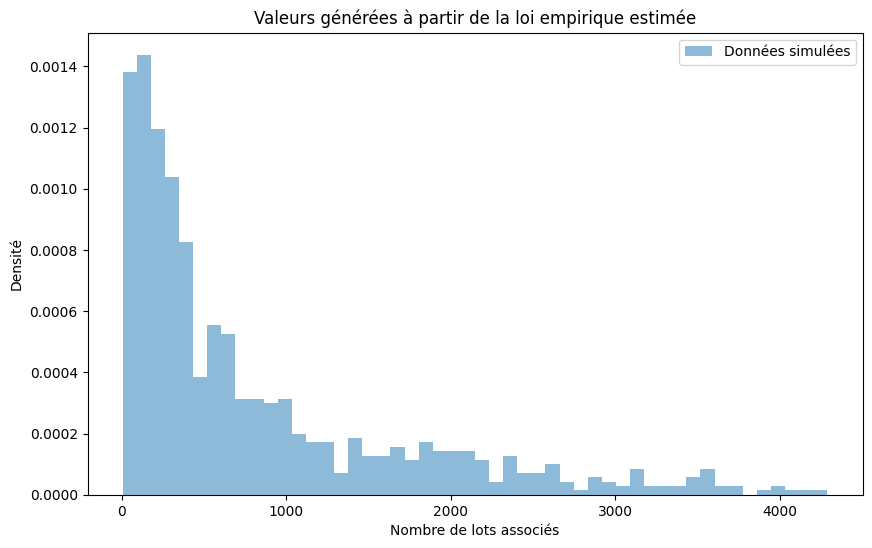

[1527, 982, 1394, 63, 249, 2383, 1759, 142, 442, 147, 35, 2233, 1790, 2068, 619, 320, 476, 1207, 390, 177, 1952, 678, 33, 1235, 960, 749, 3414, 906, 65, 29, 713, 205, 602, 1558, 1639, 332, 214, 130, 776, 1195, 89, 65, 7, 263, 2009, 292, 456, 313, 142, 430, 2380, 219, 1940, 653, 884, 3123, 2612, 3965, 99, 184, 3633, 1831, 1705, 127, 304, 638, 142, 44, 253, 268, 80, 140, 2467, 605, 30, 271, 36, 360, 180, 90, 103, 247, 230, 982, 1871, 179, 3522, 2975, 1010, 155, 594, 92, 1738, 605, 81, 2586, 1401, 254, 179, 1266, 533, 168, 560, 417, 3014, 1007, 784, 1495, 502, 1437, 1119, 345, 1380, 967, 61, 234, 604, 17, 116, 65, 8, 564, 1013, 270, 248, 1670, 170, 1428, 2311, 81, 1142, 1097, 341, 2210, 147, 539, 135, 800, 93, 83, 203, 620, 140, 580, 780, 1095, 726, 88, 2327, 414, 704, 648, 3711, 821, 75, 675, 113, 74, 360, 239, 583, 540, 149, 57, 411, 1113, 54, 927, 566, 1129, 139, 969, 390, 322, 195, 58, 129, 860, 1394, 549, 350, 3230, 124, 319, 3544, 79, 506, 1869, 141, 925, 102, 298, 779, 434, 2280, 4

In [ ]:
kde_nb_lots_negos = gaussian_kde(gestion_de_lots_negociateurs['nombre_lots_associes'].values, bw_method='scott')
valeurs_simulees_nb_lots_negos = np.floor(kde_nb_lots_negos.resample(1000)[0]).astype(int)
valeurs_simulees_nb_lots_negos = [x for x in valeurs_simulees_nb_lots_negos if x > 0]

# Afficher la distribution simulée
plt.figure(figsize=(10, 6))
plt.hist(valeurs_simulees_nb_lots_negos, bins=50, density=True, alpha=0.5, label="Données simulées")
plt.title("Valeurs générées à partir de la loi empirique estimée")
plt.xlabel("Nombre de lots associés")
plt.ylabel("Densité")
plt.legend()
plt.show()

print(valeurs_simulees_nb_lots_negos)

In [12]:
import pickle

# Sauvegarder le modèle KDE dans un fichier
with open("kde_nb_lots_negos.pkl", "wb") as f:
    pickle.dump(kde_nb_lots_negos, f)

print("✅ Loi empirique enregistrée dans kde_nb_lots_negos.pkl")

✅ Loi empirique enregistrée dans kde_nb_lots_negos.pkl


Ca y est, on a le nombre de lots que gèreront les nouveaux négociateurs entrant sur le marché. On pourrait le voir comme le "type" du négociateur : est-ce un négociateur qui gère de grosses offres avec beaucoup de lots ? Est-ce un négociateur qui gère de nombreuses petites offres constituées d'un unique lot ?

**Une autre variable et à prendre en compte : la distribution empirique de la quantité d'argent générée par transaction en moyenne par négociateur. Ce qui aidera à affiner la manière de générer des nouveaux négociateurs.**

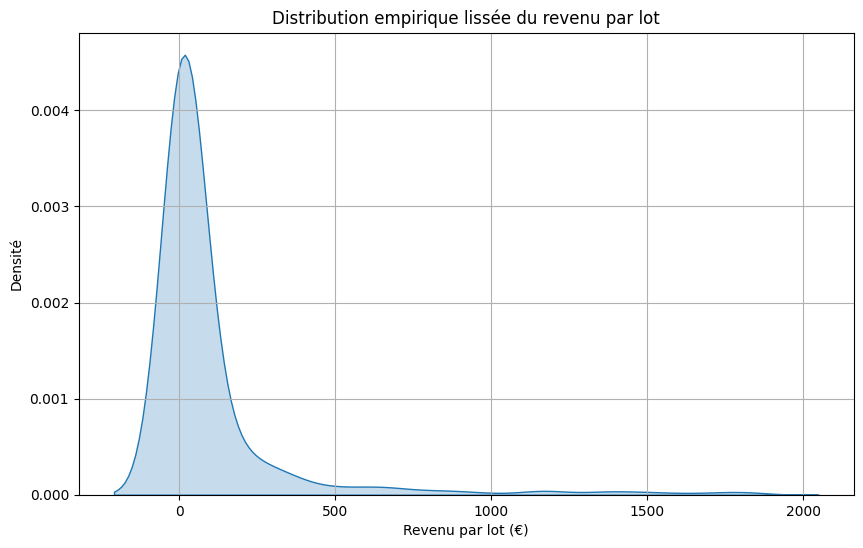

In [13]:
# Fusionner les deux DataFrames sur negociateur_id
negociateurs_revenus_par_transac = pd.merge(
    gestion_de_lots_negociateurs[['negociateur_id', 'nombre_lots_associes']],
    transactions_revenus_negociateurs[['negociateur_id', 'montant_total_transactions']],
    on='negociateur_id',
    how='inner'
)

# Calcul du ratio : montant total / nombre de lots
negociateurs_revenus_par_transac['revenu_par_lot'] = (negociateurs_revenus_par_transac['montant_total_transactions']/negociateurs_revenus_par_transac['nombre_lots_associes'])

negociateurs_revenus_par_transac = negociateurs_revenus_par_transac[negociateurs_revenus_par_transac["revenu_par_lot"] < 2000]
negociateurs_revenus_par_transac = negociateurs_revenus_par_transac[negociateurs_revenus_par_transac["revenu_par_lot"] > 0]

# Affichage du KDE
plt.figure(figsize=(10, 6))
sns.kdeplot(data=negociateurs_revenus_par_transac, x='revenu_par_lot', fill=True, bw_adjust=1)
plt.title("Distribution empirique lissée du revenu par lot")
plt.xlabel("Revenu par lot (€)")
plt.ylabel("Densité")
plt.grid(True)
plt.show()

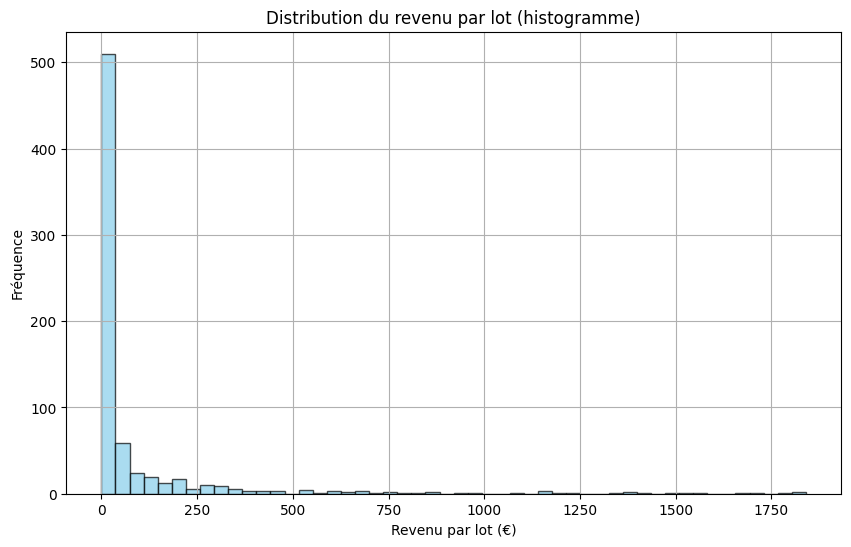

In [14]:
plt.figure(figsize=(10, 6))

# Histogramme non lissé
plt.hist(
    negociateurs_revenus_par_transac['revenu_par_lot'],
    bins=50,               # Nombre de barres
    color='skyblue',
    edgecolor='black',
    alpha=0.7
)

plt.title("Distribution du revenu par lot (histogramme)")
plt.xlabel("Revenu par lot (€)")
plt.ylabel("Fréquence")
plt.grid(True)
plt.show()

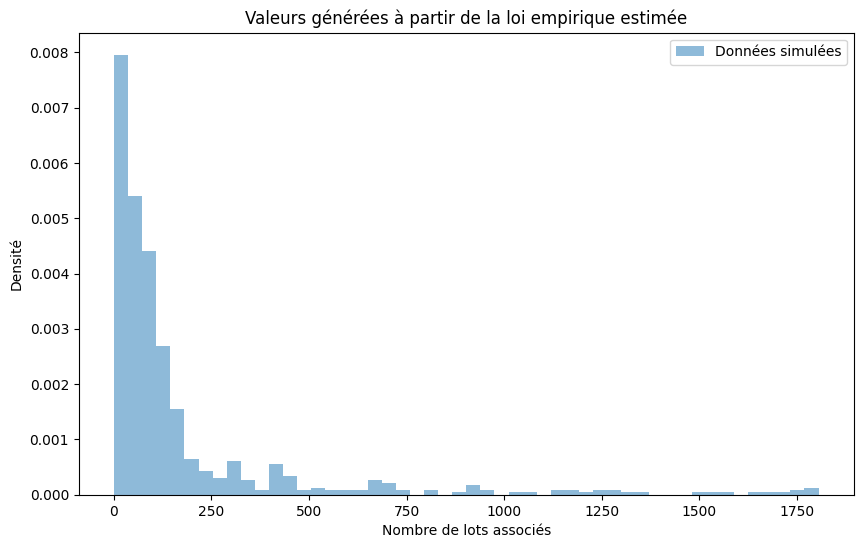

[19, 652, 414, 48, 71, 7, 32, 86, 98, 466, 23, 42, 58, 74, 202, 66, 1269, 73, 30, 151, 114, 104, 12, 624, 171, 294, 360, 928, 22, 72, 51, 70, 16, 32, 55, 57, 1766, 71, 66, 21, 15, 323, 11, 11, 13, 657, 3, 62, 595, 23, 292, 41, 102, 1256, 44, 56, 243, 448, 75, 165, 11, 18, 45, 88, 119, 65, 102, 31, 113, 80, 71, 39, 32, 162, 82, 13, 128, 56, 302, 32, 70, 156, 52, 72, 94, 65, 5, 14, 2, 83, 111, 11, 98, 15, 100, 46, 427, 157, 2, 36, 21, 129, 37, 297, 51, 146, 251, 161, 3, 38, 77, 161, 82, 511, 33, 11, 214, 122, 15, 110, 101, 87, 35, 31, 722, 13, 35, 16, 12, 32, 25, 887, 90, 229, 221, 53, 26, 190, 74, 69, 18, 166, 104, 68, 70, 366, 120, 28, 1048, 11, 64, 333, 21, 31, 28, 109, 14, 174, 157, 12, 400, 141, 87, 15, 258, 35, 36, 129, 34, 81, 164, 51, 186, 591, 54, 120, 5, 301, 38, 335, 23, 56, 14, 85, 21, 1220, 1, 57, 53, 14, 22, 73, 181, 10, 65, 62, 41, 122, 329, 11, 143, 132, 55, 74, 12, 17, 155, 45, 43, 178, 104, 106, 53, 56, 74, 929, 33, 98, 265, 437, 29, 89, 63, 308, 14, 119, 178, 24, 509, 

In [17]:
kde_revenus_par_lot = gaussian_kde(negociateurs_revenus_par_transac['revenu_par_lot'].values, bw_method='scott')

valeurs_simulees_revenus_par_lot = np.floor(kde_revenus_par_lot.resample(1000)[0]).astype(int)
valeurs_simulees_revenus_par_lot = [x for x in valeurs_simulees_revenus_par_lot if x > 0]

# Afficher la distribution simulée
plt.figure(figsize=(10, 6))
plt.hist(valeurs_simulees_revenus_par_lot, bins=50, density=True, alpha=0.5, label="Données simulées")
plt.title("Valeurs générées à partir de la loi empirique estimée")
plt.xlabel("Nombre de lots associés")
plt.ylabel("Densité")
plt.legend()
plt.show()

print(valeurs_simulees_revenus_par_lot)

In [18]:
# Sauvegarder le modèle KDE dans un fichier
with open("kde_revenus_par_lot.pkl", "wb") as f:
    pickle.dump(kde_revenus_par_lot, f)

print("✅ Loi empirique enregistrée dans kde_revenus_par_lot.pkl")

✅ Loi empirique enregistrée dans kde_revenus_par_lot.pkl
